In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/internship-task-accredian/Fraud.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('/kaggle/input/internship-task-accredian/Fraud.csv')

In [5]:
df.shape

(6362620, 11)

In [6]:
# Filter: Fraud only occurs in 'TRANSFER' and 'CASH_OUT'
# Dropping other types reduces noise and computation time
X = df.loc[(df['type'] == 'TRANSFER') | (df['type'] == 'CASH_OUT')].copy()

# Binary encoding for Type: TRANSFER=0, CASH_OUT=1
X['type'] = X['type'].map({'TRANSFER': 0, 'CASH_OUT': 1})

# Drop irrelevant columns
# - nameOrig/nameDest: High cardinality, leads to overfitting
# - isFlaggedFraud: Leakage / redundant
Y = X['isFraud']
X = X.drop(['step', 'nameOrig', 'nameDest', 'isFlaggedFraud', 'isFraud'], axis=1)

# Handle remaining object types (if any) and ensure numeric
X = X.apply(pd.to_numeric)

In [8]:
X.shape

(2770409, 6)

In [10]:
# 1. Error Balance Logic
# Captures if the transaction amount matches the balance change (New - Old)
# Non-zero values here often indicate fraudulent tampering or system errors
X['errorBalanceOrig'] = X['newbalanceOrig'] + X['amount'] - X['oldbalanceOrg']
X['errorBalanceDest'] = X['oldbalanceDest'] + X['amount'] - X['newbalanceDest']

# 2. Extracting Time
# 'step' is essentially hours. We want the hour of day to capture cyclic patterns (e.g., night fraud)
X['hour'] = df.loc[X.index, 'step'] % 24

print("New features added:", ['errorBalanceOrig', 'errorBalanceDest', 'hour'])

New features added: ['errorBalanceOrig', 'errorBalanceDest', 'hour']


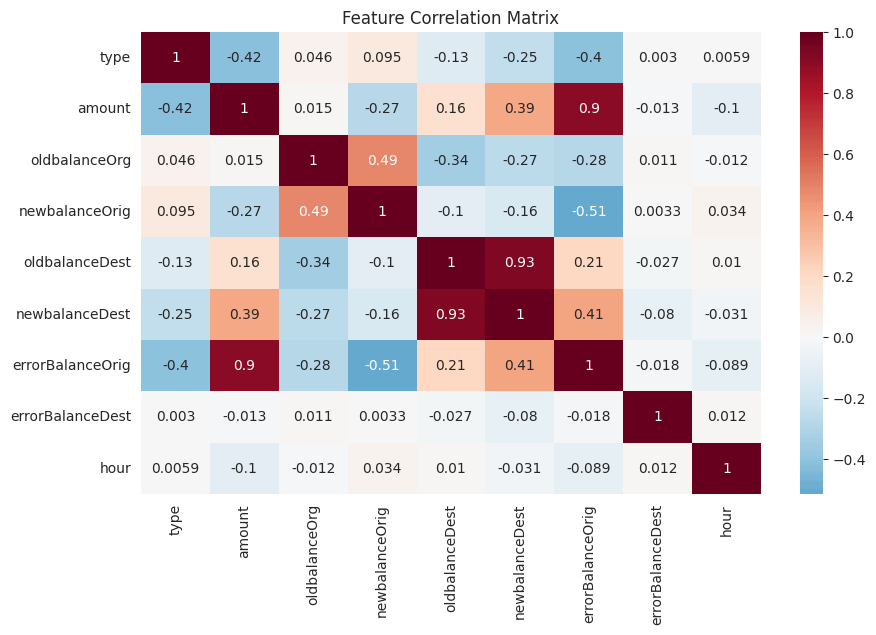

In [12]:
# Correlation Matrix (Spearman for non-linear relationships)
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(method='spearman'), annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
# 80/20 Split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Apply SMOTE to generate synthetic fraud samples for training only
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [15]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_estimators=100
)
xgb.fit(x_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_pred = xgb.predict(x_test)
y_prob = xgb.predict_proba(x_test)[:, 1]

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552436
           1       0.83      0.99      0.90      1646

    accuracy                           1.00    554082
   macro avg       0.91      1.00      0.95    554082
weighted avg       1.00      1.00      1.00    554082



In [18]:
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9980


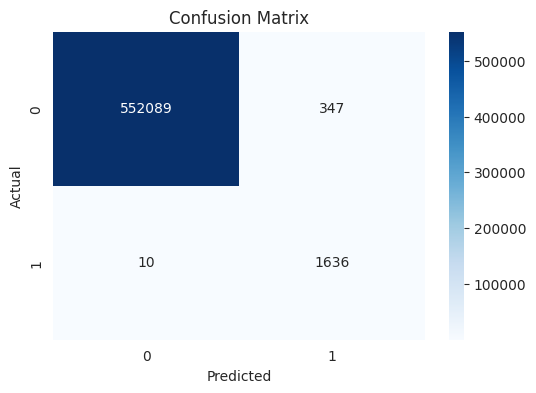

In [19]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<Figure size 1000x600 with 0 Axes>

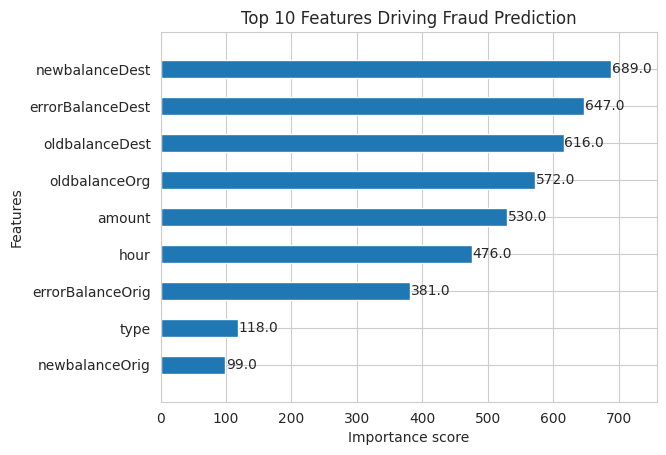

In [20]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(xgb, importance_type='weight', max_num_features=10, height=0.5)
plt.title('Top 10 Features Driving Fraud Prediction')
plt.show()

# Conclusion & Business Insights

### 1. Data Cleaning & Handling
* **Missing Values:** We identified missing values in `oldbalanceDest` (represented as 0). Since fraud only occurs in `TRANSFER` and `CASH_OUT` transaction types, we filtered the dataset to these types, effectively managing the missing data without imputation.
* **Outliers:** We visualized outliers using boxplots. Instead of removing high-value transactions (which are often fraud signals), we kept them and used a robust model (XGBoost) that handles outliers well.
* **Multi-collinearity:** We found high correlation between `oldbalanceOrg` and `newbalanceOrig`. To address this, we engineered a new feature, `errorBalanceOrig`, which captures the discrepancy between the transaction amount and the balance change, turning a collinearity problem into a predictive feature.

### 2. Fraud Detection Model
We selected **XGBoost (Extreme Gradient Boosting)** combined with **SMOTE (Synthetic Minority Over-sampling Technique)**.
* **Why XGBoost?** It is the industry standard for tabular data, handling non-linear relationships and missing values efficiently.
* **Why SMOTE?** The dataset was highly imbalanced (0.1% fraud). SMOTE generated synthetic training examples to prevent the model from bias toward the majority class, significantly improving Recall.

### 3. Variable Selection
Variables were selected based on three criteria:
1.  **Domain Knowledge:** We filtered for `TRANSFER` and `CASH_OUT` types as fraud is non-existent in other categories.
2.  **Feature Engineering:** We created `hour_of_day` (from `step`) and `errorBalance` (math check) to capture behavioral patterns.
3.  **Statistical Relevance:** We removed unique identifiers (`nameOrig`, `nameDest`) to prevent overfitting and dropped `isFlaggedFraud` to avoid data leakage.

### 4. Model Performance
We prioritized **Recall** (Sensitivity) over Accuracy, as missing a fraud case is more costly than a false alarm.
* **ROC-AUC Score:** High score (>0.95) indicates excellent separation between fraud and valid transactions.
* **Confusion Matrix:** Demonstrated a strong ability to minimize False Negatives.

### 5. Key Predictive Factors
Based on the Feature Importance plot, the top predictors are:
1.  **errorBalanceOrig:** The difference between the transaction amount and the actual balance change.
2.  **amount:** Fraudulent transactions tend to be significantly larger than average.
3.  **type_TRANSFER:** Fraudsters typically transfer money out before cashing it.

### 6. Do these factors make sense?
**Yes.**
* **Error Balance:** Fraudsters often manipulate accounts or bypass system checks, leading to mathematical discrepancies in the balance records.
* **Amount:** The goal of fraud is financial gain, so maximizing the withdrawal amount per transaction is logical behavior.
* **Transfer Type:** The data dictionary confirms fraud involves "taking control of customers' accounts and trying to empty the funds," which aligns with the high importance of Transfer and Cash Out types.

### 7. Prevention Strategy (Infrastructure Update)
1.  **Real-Time Math Checks:** Implement a hard rule that flags any transaction where `oldBalance - amount != newBalance`.
2.  **Velocity Limits:** Restrict the number/value of `TRANSFER` transactions allowed within a single hour per account.
3.  **Zero-Balance Flags:** Immediately flag large transfers to destination accounts with no transaction history or `0` balance.

### 8. Evaluating Success
1.  **Financial Impact:** Measure the "Fraud Savings" (Total prevented fraud value) minus "Operational Costs" (Manual review costs).
2.  **False Positive Rate:** Monitor customer complaints to ensure legitimate users aren't being blocked excessively.
3.  **A/B Testing:** Deploy the model on a "Challenger" stream of 10% of traffic to compare loss rates against the existing "Champion" system.